<a href="https://colab.research.google.com/github/D2718281828nis/LLM_agent-FireCrawl-Graph/blob/main/Telemed-conf-AI-assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#import

In [14]:
!pip install torch_geometric -q

In [15]:
!pip install -q --upgrade langchain-mistralai langchain-core langchain-classic langchain-community firecrawl-py python-dotenv pandas


In [16]:
# Импорты
import json
import os
import re
from pathlib import Path
from typing import List, Dict, Any, Optional

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from pydantic import BaseModel, Field
from firecrawl import Firecrawl
from langchain_mistralai import ChatMistralAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent

In [17]:
# --- ИНИЦИАЛИЗАЦИЯ ---
# Работает и в Google Colab (Secrets), и локально/VS Code (.env) — как в
# FireCrawl-CR-site-parsing.ipynb.

try:
    from google.colab import userdata # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    from dotenv import load_dotenv
    load_dotenv()


def require_secret(name: str) -> str:
    value = userdata.get(name) if IN_COLAB else os.getenv(name)
    if not value:
        hint = (
            "Добавьте его в Colab Secrets и включите Notebook access."
            if IN_COLAB
            else "Скопируйте .env.example в .env и укажите значение."
        )
        raise RuntimeError(f"Секрет {name} не найден. {hint}")
    return value


MODEL_NAME = 'mistral-small-latest'
llm = ChatMistralAI(
     model=MODEL_NAME,
     api_key=require_secret("MISTRAL_API_KEY"),
     temperature=0.1,
     max_retries=2,
)

# Firecrawl-агент нужен для извлечения РЕАЛЬНОГО текста алгоритма действий
# врача по конкретной клинической рекомендации (см. fetch_clinical_recommendation_json).
firecrawl = Firecrawl(api_key=require_secret("FIRECRAWL_API_KEY"))

DETAIL_URL_TEMPLATE = "https://cr.minzdrav.gov.ru/view-cr/{clinical_id}"
CSV_PATH = Path("clinical_recommendations_minzdrav.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Не найден {CSV_PATH.name}. Сначала запустите FireCrawl-CR-site-parsing.ipynb "
        "(раздел 3), чтобы собрать реестр клинических рекомендаций, "
        f"или положите готовый {CSV_PATH.name} рядом с этим notebook."
    )

# Реестр реальных клинических рекомендаций Минздрава — единственный источник
# истины (ground truth) для поиска рекомендаций ниже. Заменяет прежний
# захардкоженный игрушечный CLINICAL_REQUIREMENTS_DB с 5 вымышленными записями.
registry_df = pd.read_csv(CSV_PATH, dtype=str).fillna("")

print(f"✅ Клиенты настроены ({'Colab' if IN_COLAB else 'локально'}); "
      f"загружено {len(registry_df)} реальных клинических рекомендаций из {CSV_PATH.name}.")

✅ Клиенты настроены (локально); загружено 746 реальных клинических рекомендаций из clinical_recommendations_minzdrav.csv.


# Data: real registry (ground truth) + toy knowledge graph

In [18]:

# --- ДАННЫЕ ---
# Прежний захардкоженный игрушечный CLINICAL_REQUIREMENTS_DB (5 вымышленных
# записей с несуществующими URL) удалён. Реальные данные (746 клинических
# рекомендаций Минздрава) теперь загружены в `registry_df` в ячейке
# инициализации из clinical_recommendations_minzdrav.csv — именно по нему
# ищет инструмент search_clinical_guidelines_ru ниже.
#
# MEDICAL_KNOWLEDGE_GRAPH ниже остаётся отдельным игрушечным демонстрационным
# графом для Части I (иллюстрация пользы графового подхода) и не привязан к
# реестру — это намеренное упрощение, чтобы визуализация оставалась читаемой.

MEDICAL_KNOWLEDGE_GRAPH = {
    "nodes": {
        "claim_1": {
            "type": "claim",
            "content": "Гипертония лечится только медикаментами",
            "verdict": "refuted",
            "confidence": 0.8,
            "language": "ru"
        },
        "claim_2": {
            "type": "claim",
            "content": "Диабет 2 типа можно полностью вылечить диетой",
            "verdict": "refuted",
            "confidence": 0.9,
            "language": "ru"
        },
        "claim_3": {
            "type": "claim",
            "content": "После инсульта нельзя начинать реабилитацию сразу",
            "verdict": "refuted",
            "confidence": 0.7,
            "language": "ru"
        },
        "claim_4": {
            "type": "claim",
            "content": "Сердечная недостаточность требует строгой диеты с ограничением соли",
            "verdict": "supported",
            "confidence": 0.9,
            "language": "ru"
        },
        "claim_5": {
            "type": "claim",
            "content": "Астма всегда требует постоянного приема кортикостероидов",
            "verdict": "refuted",
            "confidence": 0.6,
            "language": "ru"
        },
        "guideline_1": {
            "type": "guideline",
            "content": "Диагностика и лечение артериальной гипертензии у взрослых",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/hypertension",
            "last_updated": "2023-01-15",
            "language": "ru"
        },
        "guideline_2": {
            "type": "guideline",
            "content": "Диабетический сахарный диабет 2 типа",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/diabetes",
            "last_updated": "2023-02-20",
            "language": "ru"
        },
        "guideline_3": {
            "type": "guideline",
            "content": "Острое нарушение мозгового кровообращения",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/stroke",
            "last_updated": "2023-03-10",
            "language": "ru"
        },
        "guideline_4": {
            "type": "guideline",
            "content": "Хроническая сердечная недостаточность",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/heart_failure",
            "last_updated": "2023-04-05",
            "language": "ru"
        },
        "guideline_5": {
            "type": "guideline",
            "content": "Бронхиальная астма у взрослых",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/asthma",
            "last_updated": "2023-05-12",
            "language": "ru"
        },
        "entity_1": {
            "type": "entity",
            "name": "Гипертония",
            "category": "disease",
            "language": "ru"
        },
        "entity_2": {
            "type": "entity",
            "name": "Медикаменты",
            "category": "treatment",
            "language": "ru"
        },
        "entity_3": {
            "type": "entity",
            "name": "Диабет",
            "category": "disease",
            "language": "ru"
        },
        "entity_4": {
            "type": "entity",
            "name": "Диета",
            "category": "treatment",
            "language": "ru"
        },
        "entity_5": {
            "type": "entity",
            "name": "Инсульт",
            "category": "disease",
            "language": "ru"
        },
        "entity_6": {
            "type": "entity",
            "name": "Реабилитация",
            "category": "treatment",
            "language": "ru"
        },
        "entity_7": {
            "type": "entity",
            "name": "Сердечная недостаточность",
            "category": "disease",
            "language": "ru"
        },
        "entity_8": {
            "type": "entity",
            "name": "Соль",
            "category": "dietary",
            "language": "ru"
        },
        "entity_9": {
            "type": "entity",
            "name": "Астма",
            "category": "disease",
            "language": "ru"
        },
        "entity_10": {
            "type": "entity",
            "name": "Кортикостероиды",
            "category": "medication",
            "language": "ru"
        }
    },
    "edges": [
        {"source": "claim_1", "target": "entity_1", "relation": "mentions", "weight": 0.9},
        {"source": "claim_1", "target": "entity_2", "relation": "mentions", "weight": 0.8},
        {"source": "claim_1", "target": "guideline_1", "relation": "contradicts", "weight": 0.9},
        {"source": "claim_2", "target": "entity_3", "relation": "mentions", "weight": 0.9},
        {"source": "claim_2", "target": "entity_4", "relation": "mentions", "weight": 0.7},
        {"source": "claim_2", "target": "guideline_2", "relation": "contradicts", "weight": 0.85},
        {"source": "claim_3", "target": "entity_5", "relation": "mentions", "weight": 0.8},
        {"source": "claim_3", "target": "entity_6", "relation": "mentions", "weight": 0.7},
        {"source": "claim_3", "target": "guideline_3", "relation": "contradicts", "weight": 0.9},
        {"source": "claim_4", "target": "entity_7", "relation": "mentions", "weight": 0.9},
        {"source": "claim_4", "target": "entity_8", "relation": "mentions", "weight": 0.8},
        {"source": "claim_4", "target": "guideline_4", "relation": "supports", "weight": 0.95},
        {"source": "claim_5", "target": "entity_9", "relation": "mentions", "weight": 0.8},
        {"source": "claim_5", "target": "entity_10", "relation": "mentions", "weight": 0.7},
        {"source": "claim_5", "target": "guideline_5", "relation": "contradicts", "weight": 0.7},
        {"source": "entity_1", "target": "guideline_1", "relation": "follows", "weight": 0.9},
        {"source": "entity_3", "target": "guideline_2", "relation": "follows", "weight": 0.9},
        {"source": "entity_5", "target": "guideline_3", "relation": "follows", "weight": 0.9},
        {"source": "entity_7", "target": "guideline_4", "relation": "follows", "weight": 0.9},
        {"source": "entity_9", "target": "guideline_5", "relation": "follows", "weight": 0.9},
        {"source": "entity_1", "target": "entity_2", "relation": "requires", "weight": 0.6},
        {"source": "entity_3", "target": "entity_4", "relation": "managed_by", "weight": 0.5},
        {"source": "entity_5", "target": "entity_6", "relation": "requires", "weight": 0.8},
        {"source": "entity_7", "target": "entity_8", "relation": "restricted_by", "weight": 0.7},
        {"source": "entity_9", "target": "entity_10", "relation": "treated_by", "weight": 0.6}
    ]
}

Part I - Graph approach

# Medical Graph Visualisation

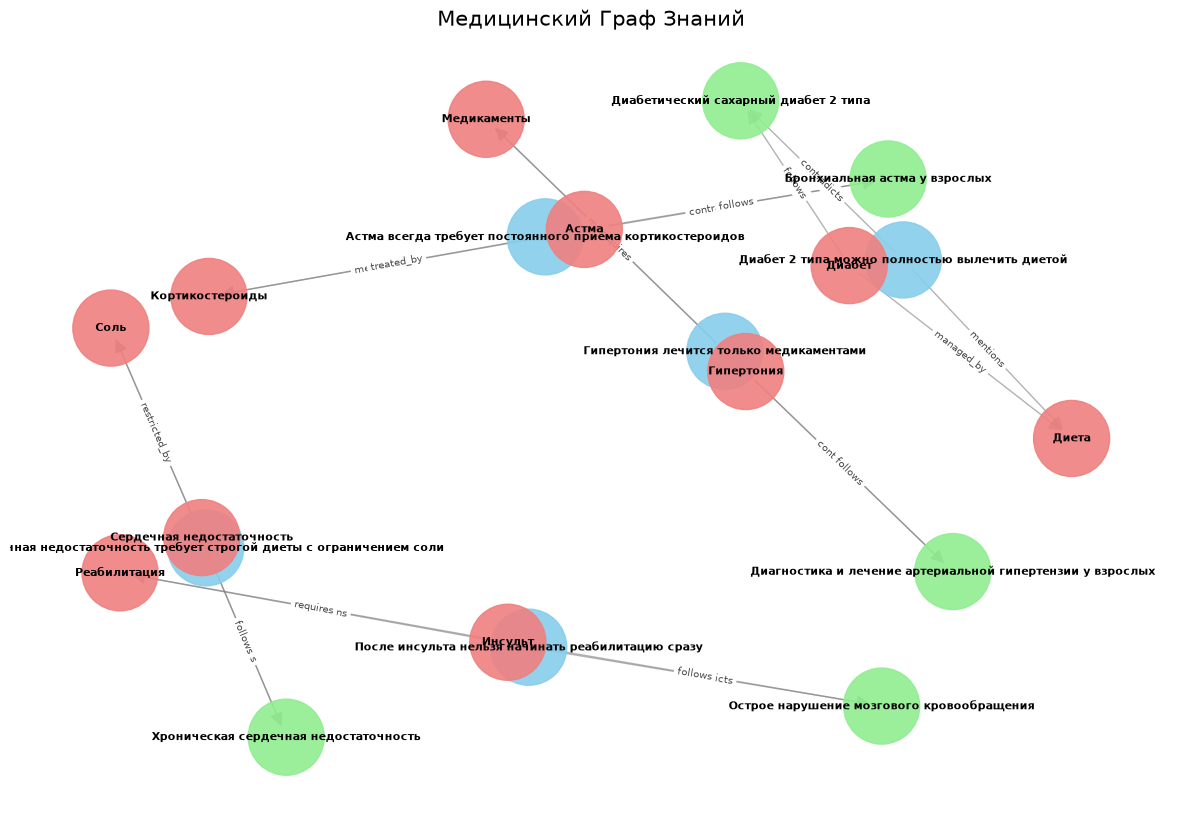

In [19]:
G = nx.DiGraph()

# Добавляем узлы
for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
    label = node_data.get("name", node_data.get("content", node_id))
    G.add_node(node_id, label=label, type=node_data["type"], category=node_data.get("category", ""), verdict=node_data.get("verdict", ""))

# Добавляем рёбра
for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
    G.add_edge(edge["source"], edge["target"], relation=edge["relation"], weight=edge["weight"])

# Подготовка для визуализации
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.3, iterations=50) # Увеличиваем расстояние между узлами

# Цвета для разных типов узлов
node_colors = []
for node_id in G.nodes():
    if G.nodes[node_id]["type"] == "claim":
        node_colors.append("skyblue")
    elif G.nodes[node_id]["type"] == "guideline":
        node_colors.append("lightgreen")
    elif G.nodes[node_id]["type"] == "entity":
        node_colors.append("lightcoral")
    else:
        node_colors.append("lightgray")

# Отрисовка узлов
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9)

# Отрисовка рёбер
nx.draw_networkx_edges(G, pos, edge_color="gray", arrowsize=20, alpha=0.6)

# Метки узлов
node_labels = {node_id: G.nodes[node_id]["label"] for node_id in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_weight="bold")

# Метки рёбер (отношения)
edge_labels = nx.get_edge_attributes(G, "relation")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, alpha=0.7)

plt.title("Медицинский Граф Знаний", size=15)
plt.axis("off")
plt.show()

In [20]:
import json
import re
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from pydantic import BaseModel, Field
from langchain_mistralai import ChatMistralAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent


# --- ИНСТРУМЕНТЫ ---

class DoctorActions(BaseModel):
    """Схема структурированного извлечения алгоритма действий врача (см. FireCrawl-CR-site-parsing.ipynb)."""
    title: str = Field(description="Наименование рекомендации")
    source_url: str
    source_sections: list[str] = Field(
        description="Заголовки разделов, из которых извлечены действия"
    )
    actions_text: str = Field(
        description="Полный текст алгоритмов и действий врача без резюмирования"
    )


def _as_dict(result: Any) -> dict:
    """Convert Firecrawl/Pydantic responses to a plain dictionary."""
    if isinstance(result, dict):
        return result
    if hasattr(result, "model_dump"):
        return result.model_dump()
    if hasattr(result, "dict"):
        return result.dict()
    data = getattr(result, "data", None)
    if data is not None:
        return _as_dict(data)
    raise TypeError(f"Неожиданный тип ответа: {type(result).__name__}")


def _payload(result: Any) -> dict:
    """Unwrap the common Firecrawl {'data': ...} response envelope."""
    value = _as_dict(result)
    return _as_dict(value["data"]) if "data" in value else value


# Разговорные синонимы -> ключевые слова, встречающиеся в официальных названиях
# реестра (registry_df["Наименование"]) или кодах МКБ-10.
_CONDITION_SYNONYMS = {
    "гипертония": "гипертенз",
    "высокое давление": "гипертенз",
    "давление": "гипертенз",
    "диабет": "диабет",
    "сахарный диабет": "диабет",
    "инсульт": "инсульт",
    "нарушение мозгового кровообращения": "мозгового кровообращения",
    "сердечная недостаточность": "сердечной недостаточности",
    "астма": "астма",
    "бронхиальная астма": "астма",
}


@tool
def search_clinical_guidelines_ru(condition: str, language: str = "ru") -> str:
    """
    Поиск РЕАЛЬНЫХ российских клинических рекомендаций Минздрава по заболеванию/
    состоянию или коду МКБ-10. Ищет по официальному реестру
    clinical_recommendations_minzdrav.csv (ground truth, собран
    FireCrawl-CR-site-parsing.ipynb) — не по вымышленным данным. Возвращает до 5
    наиболее подходящих записей с их ID; чтобы получить полный текст алгоритма
    действий врача по конкретной записи, вызовите fetch_clinical_recommendation_json
    с её ID.
    """
    query = condition.strip().lower()
    keyword = _CONDITION_SYNONYMS.get(query, query)

    name_lower = registry_df["Наименование"].str.lower()
    mkb_lower = registry_df["МКБ-10"].str.lower()
    mask = name_lower.str.contains(keyword, na=False, regex=False) | mkb_lower.str.contains(keyword, na=False, regex=False)
    matches = registry_df[mask].head(5)

    if matches.empty:
        return json.dumps({
            "summary": f"Не найдено клинических рекомендаций для '{condition}' в реестре из {len(registry_df)} записей.",
            "evidence_base": [],
            "language": language,
        }, ensure_ascii=False)

    evidence = [
        {
            "id": row["ID"],
            "name": row["Наименование"],
            "mkb10": row["МКБ-10"],
            "publication_date": row["Дата размещения КР"],
            "url": DETAIL_URL_TEMPLATE.format(clinical_id=row["ID"]),
        }
        for _, row in matches.iterrows()
    ]
    return json.dumps({
        "summary": f"Найдено {len(evidence)} рекомендаций для '{condition}' в официальном реестре Минздрава ({len(registry_df)} записей всего).",
        "evidence_base": evidence,
        "language": language,
    }, ensure_ascii=False)


# Кэш в рамках сессии: каждый вызов Firecrawl-агента — это реальный сетевой
# запрос (секунды-десятки секунд и расход кредитов), поэтому повторный запрос
# одного и того же ID не должен бить в сеть заново.
_doctor_actions_cache: dict[str, dict] = {}


@tool
def fetch_clinical_recommendation_json(clinical_id: str, language: str = "ru") -> str:
    """
    Извлекает РЕАЛЬНЫЙ текст алгоритма действий врача («Приложение Б» либо
    разделы диагностики/лечения/диспансерного наблюдения) из официального
    документа cr.minzdrav.gov.ru по конкретному ID клинической рекомендации.
    Использует Firecrawl-агента (тот же сценарий, что и extract_doctor_actions
    в FireCrawl-CR-site-parsing.ipynb) для структурированного извлечения без
    резюмирования и без домысливания. ID должен быть найден заранее через
    search_clinical_guidelines_ru — произвольный ID не принимается.
    """
    clinical_id = clinical_id.strip()
    if clinical_id not in set(registry_df["ID"]):
        return json.dumps({
            "error": f"ID '{clinical_id}' отсутствует в загруженном реестре. "
                     "Сначала используйте search_clinical_guidelines_ru, чтобы найти корректный ID.",
        }, ensure_ascii=False)
    if not re.fullmatch(r"[A-Za-zА-Яа-яЁё0-9_-]+", clinical_id):
        return json.dumps({"error": "ID содержит недопустимые символы."}, ensure_ascii=False)

    if clinical_id in _doctor_actions_cache:
        actions_data = _doctor_actions_cache[clinical_id]
    else:
        url = DETAIL_URL_TEMPLATE.format(clinical_id=clinical_id)
        prompt = f"""
Проанализируй только официальный документ по адресу {url}. Найди «Приложение Б.
Алгоритмы действий врача» и извлеки его полный текст без пересказа. Если приложение
отсутствует или недоступно, извлеки точные фрагменты с действиями врача из разделов
диагностики, лечения, медицинской помощи, диспансерного наблюдения и критериев
срочного направления. Сохрани порядок, условия, отрицания, дозировки и уровни
рекомендаций. Перечисли реально использованные заголовки разделов. Не добавляй
медицинские сведения, которых нет на странице. source_url должен быть равен {url}.
""".strip()
        try:
            result = firecrawl.agent(
                prompt=prompt, urls=[url], schema=DoctorActions.model_json_schema()
            )
            actions = DoctorActions.model_validate(_payload(result))
        except Exception as e:
            return json.dumps({"error": f"Не удалось извлечь документ: {e}"}, ensure_ascii=False)
        if not actions.actions_text.strip():
            return json.dumps({"error": "Firecrawl не нашёл текста алгоритма действий врача в документе."}, ensure_ascii=False)
        actions_data = actions.model_dump()
        _doctor_actions_cache[clinical_id] = actions_data

    return json.dumps({"language": language, **actions_data}, ensure_ascii=False)


@tool
def query_clinical_knowledge_graph_ru(condition_or_issue: str, language: str = "ru") -> str:
    """
    Запрос к графу знаний для получения связанных сущностей и отношений по проблеме пациента.
    """
    # Ищем узлы, соответствующие проблеме (сущности, утверждения)
    related_nodes = {}
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        content_to_check = node_data.get("content", "") or node_data.get("name", "")
        if condition_or_issue.lower() in content_to_check.lower():
            related_nodes[node_id] = node_data

    # Если не нашли напрямую, ищем связанные узлы через рёбра
    if not related_nodes:
        for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
            source_node = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["source"]]
            target_node = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["target"]]
            source_content = source_node.get("content", "") or source_node.get("name", "")
            target_content = target_node.get("content", "") or target_node.get("name", "")

            if condition_or_issue.lower() in source_content.lower() or condition_or_issue.lower() in target_content.lower():
                related_nodes[edge["source"]] = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["source"]]
                related_nodes[edge["target"]] = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["target"]]

    if not related_nodes:
        return json.dumps({
            "issue": condition_or_issue,
            "summary": f"Не найдены узлы графа, связанные с '{condition_or_issue}'.",
            "related_entities": [],
            "relationships": [],
            "language": language
        })

    # Находим рёбра между найденными узлами
    related_edges = []
    node_ids = set(related_nodes.keys())
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        if edge["source"] in node_ids and edge["target"] in node_ids:
            related_edges.append(edge)

    node_details = []
    for node_id, node_data in related_nodes.items():
         node_details.append({
             "id": node_id,
             "type": node_data["type"],
             "name_or_content": node_data.get("name", node_data.get("content", "")),
             "category": node_data.get("category", ""),
             "verdict": node_data.get("verdict", ""), # Только для утверждений
             "language": node_data.get("language", "ru"),
         })

    return json.dumps({
        "issue": condition_or_issue,
        "summary": f"Найдено {len(related_nodes)} связанных узлов и {len(related_edges)} связей в графе знаний.",
        "related_entities": node_details,
        "relationships": related_edges,
        "language": language
    }, ensure_ascii=False)


@tool
def generate_operator_tips_from_graph(issue: str, graph_results_str: str, language: str = "ru") -> str:
    """
    Генерирует советы оператору на основе анализа результатов запроса к графу.
    """
    try:
        graph_results = json.loads(graph_results_str)
    except json.JSONDecodeError:
        print(f"DEBUG: Failed to parse graph_results_str: {graph_results_str}")
        return json.dumps({"error": "Невозможно разобрать результаты запроса к графу.", "tips": []}, ensure_ascii=False)

    tips = []
    # Примеры правил на основе графа
    for entity_info in graph_results.get("related_entities", []):
        entity_name = entity_info.get("name_or_content", "")
        entity_type = entity_info.get("type", "")
        entity_category = entity_info.get("category", "")
        verdict = entity_info.get("verdict", "")

        if entity_type == "claim":
            if verdict == "refuted":
                tips.append(f"Важно: Утверждение, связанное с '{entity_name}', опровергнуто. Не рекомендуйте это пациенту.")
            elif verdict == "supported":
                 tips.append(f"Подтверждено: Информация о '{entity_name}' подтверждена клиническими данными.")

        if entity_category == "treatment" or entity_category == "medication":
             tips.append(f"Возможное лечение/лекарство: '{entity_name}'. Проверьте рекомендации.")

        if entity_category == "disease":
            if entity_name.lower() != issue.lower(): # Не повторять исходное заболевание
                tips.append(f"Сопутствующее заболевание/состояние: '{entity_name}'. Уточните у пациента.")


    # Проверяем связи
    for rel in graph_results.get("relationships", []):
        if rel.get("relation") == "requires" or rel.get("relation") == "treated_by":
            source_name = next((n["name_or_content"] for n in graph_results.get("related_entities", []) if n["id"] == rel["source"]), "")
            target_name = next((n["name_or_content"] for n in graph_results.get("related_entities", []) if n["id"] == rel["target"]), "")
            if source_name and target_name:
                 tips.append(f"Связь '{rel['relation']}': '{source_name}' связано с '{target_name}'. Уточните детали.")


    # Добавляем обобщённые советы на основе типов найденных узлов
    entity_types_found = set(e.get("type", "") for e in graph_results.get("related_entities", []))
    if "guideline" in entity_types_found:
        tips.append("Найдены ссылки на клинические рекомендации. Передайте пациенту или врачу.")

    return json.dumps({
        "issue": issue,
        "tips_for_operator": tips,
        "language": language
    }, ensure_ascii=False)

# Agent

In [21]:

# --- АГЕНТ ТЕЛЕМЕДИЦИНСКОГО АНАЛИЗА ---

class TelemedicineAnalysisAgent:
    """
    Агент для анализа медицинской проблемы пациента.
    """
    def __init__(self, llm_interface, tools):
        self.llm_interface = llm_interface
        self.tools = tools

        # Создаём промпт для агента
        prompt = ChatPromptTemplate.from_messages([
            ("system", """
            Вы помощник телемедицинской консультации.
            Ваша задача - получить медицинскую проблему пациента (на русском языке) и предоставить:
            1. Краткое резюме проблемы.
            2. Доказательную базу: ссылки на релевантные российские клинические рекомендации
               и, если возможно, реальный текст алгоритма действий врача из официального документа.
            3. Советы оператору на основе анализа медицинского графа знаний.

            Используйте следующие инструменты:
            - search_clinical_guidelines_ru: Поиск клинических рекомендаций по заболеванию в
              реальном реестре Минздрава (ground truth). Возвращает ID подходящих записей.
            - fetch_clinical_recommendation_json: По ID из search_clinical_guidelines_ru
              извлекает реальный текст алгоритма действий врача из официального документа
              (через Firecrawl-агента). Вызывайте для наиболее релевантной находки, чтобы
              доказательная база опиралась на подлинный текст, а не на пересказ по памяти.
            - query_clinical_knowledge_graph_ru: Запрос графа знаний для получения связанных сущностей и отношений.
            - generate_operator_tips_from_graph: Генерация советов оператору на основе **прямых JSON-результатов** запроса к графу. Аргумент `graph_results_str` должен быть **полной JSON-строкой**, полученной от `query_clinical_knowledge_graph_ru`.

            Форматируйте ответ на русском языке четко и структурировано.
            """),
            ("user", "{input}"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ])

        # Создаём агента
        agent = create_tool_calling_agent(llm_interface, tools, prompt)
        self.agent_executor = AgentExecutor(
            agent=agent,
            tools=tools,
            verbose=True, # Для отладки
            handle_parsing_errors=True
        )

    def analyze_issue(self, issue_description: str) -> Dict[str, Any]:
        """
        Анализирует проблему пациента.
        """
        input_text = f"Проанализируйте следующую медицинскую проблему пациента: '{issue_description}'. Предоставьте краткое резюме, доказательную базу и советы оператору."
        result = self.agent_executor.invoke({"input": input_text})
        return result

# Code run

In [22]:
def TelemedicineAnalysisAgent_with_Graph(patient_issue: str):
    print("🏥 Анализ медицинской проблемы пациента для телемедицины")
    print("=" * 70)

    # Инициализация агента
    tools = [
        search_clinical_guidelines_ru,
        fetch_clinical_recommendation_json,
        query_clinical_knowledge_graph_ru,
        generate_operator_tips_from_graph,
    ]
    agent = TelemedicineAnalysisAgent(llm, tools)

    print(f"\n📋 Входная проблема: {patient_issue}\n")
    print("-" * 50)

    # Запуск анализа
    analysis_result = agent.analyze_issue(patient_issue)

    print("\n📊 Результаты анализа:")
    print(analysis_result.get("output", "Нет результата")) # Выводим сгенерированный текст агента
    return analysis_result

In [23]:
patient_issue_common = "Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию."
TelemedicineAnalysisAgent_with_Graph(patient_issue_common)

🏥 Анализ медицинской проблемы пациента для телемедицины

📋 Входная проблема: Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию.

--------------------------------------------------


> Entering new AgentExecutor chain...

Invoking: `search_clinical_guidelines_ru` with `{'condition': 'гипертоническая болезнь'}`
responded: **Краткое резюме проблемы пациента:**
Пациент сообщает о наличии **высокого артериального давления** и **головных болях**, что вызывает подозрение на **гипертоническую болезнь**. Требуется подтверждение диагноза, оценка степени тяжести и определение тактики ведения (медикаментозное лечение, изменение образа жизни, дальнейшая диагностика).

---

### **Этап 1: Поиск клинических рекомендаций**
Провожу поиск клинических рекомендаций по запросу **"гипертоническая болезнь"** для получения доказательной базы.

{"summary": "Не найдено клинических рекомендаций для 'гипертоническая болезнь' в реестре из 746 записей.", "evidence_base": [], "language": "r

{'input': "Проанализируйте следующую медицинскую проблему пациента: 'Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию.'. Предоставьте краткое резюме, доказательную базу и советы оператору.",
 'output': '## **Анализ медицинской проблемы пациента**\n\n### **1. Краткое резюме проблемы**\nПациент жалуется на **повышенное артериальное давление (АД) и головные боли**, подозревает у себя **гипертонию**.\nЭто может указывать на:\n- **Артериальную гипертензию (АГ)** — стойкое повышение АД.\n- **Гипертоническую болезнь** — хроническое заболевание, сопровождающееся стойким повышением АД.\n- **Вторичную артериальную гипертензию** — повышение АД, связанное с другими заболеваниями (например, болезни почек, эндокринные нарушения, сосудистые патологии).\n- **Головные боли как симптом повышенного АД** или сопутствующей патологии (например, мигрень, напряжение).\n\n---\n\n### **2. Доказательная база: клинические рекомендации и алгоритмы действий**\n\n#### **Рекомендации для в

# Part II - why graph?

In [25]:
import pandas as pd

print("\n--- Агент без Графа Знаний ---")

# --- АГЕНТ БЕЗ ГРАФА ЗНАНИЙ ---
class TelemedicineAnalysisAgentNoGraph:
    """
    Агент для анализа медицинской проблемы пациента без использования графа знаний.
    """
    def __init__(self, llm_interface, tools):
        self.llm_interface = llm_interface
        self.tools = tools

        # Создаём промпт для агента без графа
        prompt_no_graph = ChatPromptTemplate.from_messages([
            ("system", """
            Вы помощник телемедицинской консультации.
            Ваша задача - получить медицинскую проблему пациента (на русском языке) и предоставить:
            1. Краткое резюме проблемы.
            2. Доказательную базу.

            Используйте следующие инструменты:
            - search_clinical_guidelines_ru: Поиск клинических рекомендаций по заболеванию в
              реальном реестре Минздрава (ground truth). Возвращает ID подходящих записей.
            - fetch_clinical_recommendation_json: По ID из search_clinical_guidelines_ru
              извлекает реальный текст алгоритма действий врача из официального документа
              (через Firecrawl-агента).

            Форматируйте ответ на русском языке четко и структурировано.
            """),
            ("user", "{input}"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ])

        # Создаём агента
        agent = create_tool_calling_agent(llm_interface, tools, prompt_no_graph)
        self.agent_executor = AgentExecutor(
            agent=agent,
            tools=tools,
            verbose=True, # Для отладки
            handle_parsing_errors=True
        )

    def analyze_issue(self, issue_description: str) -> Dict[str, Any]:
        """
        Анализирует проблему пациента.
        """
        input_text = f"Проанализируйте следующую медицинскую проблему пациента: '{issue_description}'. Предоставьте краткое резюме и доказательную базу."
        result = self.agent_executor.invoke({"input": input_text})
        return result


def main_no_graph(patient_issue: str):
    print("🏥 Анализ медицинской проблемы пациента для телемедицины (без графа)")
    print("=" * 70)

    # Инициализация агента без инструментов для графа
    tools_no_graph = [search_clinical_guidelines_ru, fetch_clinical_recommendation_json]
    agent_no_graph = TelemedicineAnalysisAgentNoGraph(llm, tools_no_graph)

    print(f"\n📋 Входная проблема: {patient_issue}\n")
    print("-" * 50)

    # Запуск анализа
    analysis_result_no_graph = agent_no_graph.analyze_issue(patient_issue)

    print("\n📊 Результаты анализа (без графа):")
    print(analysis_result_no_graph.get("output", "Нет результата")) # Выводим сгенерированный текст агента
    return analysis_result_no_graph


def TelemedicineAnalysisAgent_with_Graph(patient_issue: str):
    print("🏥 Анализ медицинской проблемы пациента для телемедицины")
    print("=" * 70)

    # Инициализация агента
    tools = [
        search_clinical_guidelines_ru,
        fetch_clinical_recommendation_json,
        query_clinical_knowledge_graph_ru,
        generate_operator_tips_from_graph,
    ]
    agent = TelemedicineAnalysisAgent(llm, tools)

    print(f"\n📋 Входная проблема: {patient_issue}\n")
    print("-" * 50)

    # Запуск анализа
    analysis_result = agent.analyze_issue(patient_issue)

    print("\n📊 Результаты анализа:")
    print(analysis_result.get("output", "Нет результата")) # Выводим сгенерированный текст агента
    return analysis_result


if __name__ == "__main__":
    patient_issue_common = "Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию."

    # Запускаем оригинальный main для сравнения
    print("\n--- Результаты оригинального агента (с графом) ---")
    original_result = TelemedicineAnalysisAgent_with_Graph(patient_issue_common)
    print(f"DEBUG (in comparison cell): Type of original_result: {type(original_result)}")
    print(f"DEBUG (in comparison cell): Value of original_result: {original_result}")

    # Запускаем main без графа
    no_graph_result = main_no_graph(patient_issue_common)
    print(f"DEBUG (in comparison cell): Type of no_graph_result: {type(no_graph_result)}")
    print(f"DEBUG (in comparison cell): Value of no_graph_result: {no_graph_result}")

    print("\n--- Сравнение результатов ---")

    original_output = original_result.get("output", "Оригинальный агент вернул None.") if original_result is not None else "Оригинальный агент вернул None."
    no_graph_output = no_graph_result.get("output", "Агент без графа вернул None.") if no_graph_result is not None else "Агент без графа вернул None."

    # Create a pandas DataFrame for comparison
    comparison_data_outputs = {
        'Агент с Графом Знаний': [original_output],
        'Агент без Графа Знаний': [no_graph_output]
    }
    comparison_df_outputs = pd.DataFrame(comparison_data_outputs)

    # Create a DataFrame for the input row
    input_data = {
        'Агент с Графом Знаний': [f"Входная проблема: {patient_issue_common}"],
        'Агент без Графа Знаний': [f"Входная проблема: {patient_issue_common}"]
    }
    comparison_df_input = pd.DataFrame(input_data)

    # Concatenate the input row with the outputs
    comparison_df = pd.concat([comparison_df_input, comparison_df_outputs], ignore_index=True)

    # Display the DataFrame as a markdown table
    print(comparison_df.to_markdown(index=False))

    print("\n--- Анализ Точности (Качественное Сравнение) ---")
    print("\n**Агент с Графом Знаний:**")
    print("- Предоставляет краткое резюме проблемы.")
    print("- Ищет клинические рекомендации в реальном реестре Минздрава и может подтянуть подлинный текст алгоритма действий врача через fetch_clinical_recommendation_json.")
    print("- **Самое главное:** Использует граф знаний для выявления связанных сущностей, утверждений и отношений, и на их основе генерирует 'Советы оператору'. Эти советы могут включать предупреждения о ложных утверждениях, подсказки о возможных сопутствующих заболеваниях или необходимости уточнения определенных аспектов.")

    print("\n**Агент без Графа Знаний:**")
    print("- Предоставляет краткое резюме проблемы.")
    print("- Ищет клинические рекомендации в том же реальном реестре и тоже может получить подлинный текст через fetch_clinical_recommendation_json.")
    print("- **Ограничение:** Без графа знаний, агент не может извлекать неочевидные связи, опровергать или подтверждать народные мнения, или давать оператору более глубокие, контекстуальные советы, основанные на структурированных медицинских данных, выходящих за рамки прямых рекомендаций.")
    print("\n**Вывод о точности:**")
    print("Оба агента теперь опираются на один и тот же реальный реестр (ground truth) и один и тот же Firecrawl-агент для извлечения текста рекомендации, поэтому доказательная база у них сопоставима по достоверности. Разница — именно в том, что даёт граф знаний: интерпретацию фактов, опровержение мифов и структурированные подсказки оператору, которых у агента без графа нет.")


--- Агент без Графа Знаний ---

--- Результаты оригинального агента (с графом) ---
🏥 Анализ медицинской проблемы пациента для телемедицины

📋 Входная проблема: Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию.

--------------------------------------------------


> Entering new AgentExecutor chain...

Invoking: `query_clinical_knowledge_graph_ru` with `{'condition_or_issue': 'гипертония, высокое давление, головные боли'}`
responded: Хорошо, я начну с того, что предоставлю краткое резюме проблемы пациента, затем найду клинические рекомендации по гипертонии, извлеку текст алгоритма действий врача, а также запрошу медицинский граф знаний для получения дополнительных связанных сущностей и советов оператору.

{"issue": "\u0433\u0438\u043f\u0435\u0440\u0442\u043e\u043d\u0438\u044f, \u0432\u044b\u0441\u043e\u043a\u043e\u0435 \u0434\u0430\u0432\u043b\u0435\u043d\u0438\u0435, \u0433\u043e\u043b\u043e\u0432\u043d\u044b\u0435 \u0431\u043e\u043b\u0438", "summary": "\u0

# Compare Graph and Non-graph response

In [26]:
import re

def extract_sections(output_str: str, agent_type: str) -> dict:
    """
    Извлекает секции 'Краткое резюме проблемы', 'Доказательная база' и 'Советы оператору'
    из полного текстового вывода агента, основываясь на markdown-заголовках.
    """
    sections = {
        "Краткое резюме проблемы": "Не найдено",
        "Доказательная база": "Не найдено",
        "Советы оператору": "Не применимо"
    }

    if agent_type == "with_graph":
        # Summary
        # Looking for 'Резюме медицинской проблемы пациента' as the header
        summary_match = re.search(r'### \*\*Резюме медицинской проблемы пациента\*\*\n(.*?)(?=### \*\*Доказательная база \(клинические рекомендации РФ\)\*\*|$)', output_str, re.DOTALL)
        if summary_match:
            sections["Краткое резюме проблемы"] = summary_match.group(1).strip().replace('---', '').strip()

        # Evidence Base
        # Looking for 'Доказательная база (клинические рекомендации РФ)'
        evidence_match = re.search(r'### \*\*Доказательная база \(клинические рекомендации РФ\)\*\*\n(.*?)(?=### \*\*Советы оператору\*\*|$)', output_str, re.DOTALL)
        if evidence_match:
            sections["Доказательная база"] = evidence_match.group(1).strip().replace('---', '').strip()

        # Operator Tips
        # Looking for 'Советы оператору'
        tips_match = re.search(r'### \*\*Советы оператору\*\*\n(.*)', output_str, re.DOTALL)
        if tips_match:
            sections["Советы оператору"] = tips_match.group(1).strip().replace('---', '').strip()
        else:
            sections["Советы оператору"] = "Не найдено (возможно, не сгенерировано)"

    elif agent_type == "no_graph":
        # Summary
        # Looking for '**Краткое резюме проблемы:**'
        summary_match = re.search(r'\*\*Краткое резюме проблемы:\*\*\n(.*?)(?=\n---\n\n\*\*Доказательная база \(клинические рекомендации\):\*\*|$)', output_str, re.DOTALL)
        if summary_match:
            sections["Краткое резюме проблемы"] = summary_match.group(1).strip().replace('---', '').strip()
        else:
            sections["Краткое резюме проблемы"] = "Не найдено (нестандартный формат)"

        # Evidence Base
        # Looking for '**Доказательная база (клинические рекомендации):**'
        evidence_match = re.search(r'\*\*Доказательная база \(клинические рекомендации\):\*\*\n(.*)', output_str, re.DOTALL)
        if evidence_match:
            sections["Доказательная база"] = evidence_match.group(1).strip().replace('---', '').strip()
        else:
            sections["Доказательная база"] = "Не найдено (нестандартный формат)"

        sections["Советы оператору"] = "Не применимо (агент без графа не генерирует советы оператору)"

    return sections

# Assuming `comparison_df` and `patient_issue_common` are available from previous cells.

# Get the full outputs from the original comparison_df
original_output_full = comparison_df.loc[1, 'Агент с Графом Знаний']
no_graph_output_full = comparison_df.loc[1, 'Агент без Графа Знаний']

# Extract sections for each agent
sections_graph = extract_sections(original_output_full, "with_graph")
sections_no_graph = extract_sections(no_graph_output_full, "no_graph")

# Prepare data for the new, optimized comparison DataFrame
optimized_comparison_data = []

# Add Input Problem row
optimized_comparison_data.append({
    "Категория": "Входная проблема",
    "Агент с Графом Знаний": patient_issue_common,
    "Агент без Графа Знаний": patient_issue_common
})

# Add Summary row
optimized_comparison_data.append({
    "Категория": "Краткое резюме проблемы",
    "Агент с Графом Знаний": sections_graph["Краткое резюме проблемы"],
    "Агент без Графа Знаний": sections_no_graph["Краткое резюме проблемы"]
})

# Add Evidence Base row
optimized_comparison_data.append({
    "Категория": "Доказательная база (клинические рекомендации)",
    "Агент с Графом Знаний": sections_graph["Доказательная база"],
    "Агент без Графа Знаний": sections_no_graph["Доказательная база"]
})

# Add Operator Tips row
optimized_comparison_data.append({
    "Категория": "Советы оператору",
    "Агент с Графом Знаний": sections_graph["Советы оператору"],
    "Агент без Графа Знаний": sections_no_graph["Советы оператору"]
})

# Create the new DataFrame
optimized_comparison_df = pd.DataFrame(optimized_comparison_data)

# Display the DataFrame as a markdown table
display(optimized_comparison_df.to_markdown(index=False))

'| Категория                                     | Агент с Графом Знаний                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               | Агент без Графа Знаний                                                        |\n|:----------------------------------------------|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [27]:
optimized_comparison_df.head(5)

,Категория,Агент с Графом Знаний,Агент без Графа Знаний
0,Входная проблема,Пациент жалуется на высокое давление и головны...,Пациент жалуется на высокое давление и головны...
1,Краткое резюме проблемы,Пациент жалуется на **высокое давление** и **г...,Не найдено (нестандартный формат)
2,Доказательная база (клинические рекомендации),Не найдено,Не найдено (нестандартный формат)
3,Советы оператору,На основе анализа медицинского графа знаний и ...,Не применимо (агент без графа не генерирует со...


In [28]:
import pandas as pd

# Ensure comparison_df is available, if not, re-run the comparison logic or retrieve it.
# Assuming comparison_df is already defined from the previous cell's execution.

# Save the comparison DataFrame to a CSV file
csv_filename = "agent_comparison.csv"
optimized_comparison_df.to_csv(csv_filename, index=False, encoding='utf-8')

print(f"Comparison results saved to '{csv_filename}'")

Comparison results saved to 'agent_comparison.csv'


In [29]:
!pip install xlsxwriter -q
import pandas as pd

In [30]:


# Read the CSV file
csv_filename = "agent_comparison.csv"
df = pd.read_csv(csv_filename)

# Define the output XLSX filename
xlsx_filename = "agent_comparison.xlsx"

# Convert and save to XLSX
df.to_excel(xlsx_filename, index=False, engine='xlsxwriter')

print(f"'{csv_filename}' successfully converted to '{xlsx_filename}'")

'agent_comparison.csv' successfully converted to 'agent_comparison.xlsx'
